# Error Analysis — PIQA

**Benchmark:** PIQA
**Description:** Physical commonsense; pick the sensible method; 1-of-2
**Random baseline:** 50%
**Our generator(s) targeting this:** Gen B (Physical Commonsense)

This notebook drills into why the model isn't getting a higher score. It:
1. Splits every question into `answerable` / `unanswerable` / `ambiguous` using a hybrid keyword + LLM-judge classifier (cached).
2. Reports accuracy stratified by answerability — so we see real model capability, not just raw score.
3. Examines confidence on wrong answers (high-confidence wrong = learned wrong pattern).
4. Surfaces the highest-confidence wrong answers on the *answerable* subset — these are the diagnostic gold.
5. Compares Mid vs SFT phases to see where the gap closed or opened.
6. Delivers a one-line verdict: content gap, skill gap, or both.

In [1]:
import sys
from pathlib import Path

# Ensure project root is importable
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "post_training").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.post_training.analysis import (
    load_details, load_classifications, classify_batch,
    accuracy_triple, confidence_breakdown, high_confidence_wrong,
    plot_confidence_histogram, extract_stem_and_choices,
)
from src.post_training.analysis.answerability import _hash_question

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BENCHMARK = "PIQA"
RANDOM_BASELINE = 0.5

BASE = Path(r'D:/hist_LLM/periods/1900_1949/error_analysis_new')
CACHE = BASE / '.answerability_cache' / f'{BENCHMARK}.jsonl'

STAGES = ['mid_final', 'sft_final', 'sft_final_debiased']
dfs = {}
for stage in STAGES:
    p = BASE / stage / f'{BENCHMARK}_details.jsonl'
    dfs[stage] = load_details(p)
    print(f'{stage}: {len(dfs[stage])} rows')

mid_final: 464 rows
sft_final: 464 rows
sft_final_debiased: 464 rows


## 1. Answerability Classifications

Load the cached classifications. If the cache is missing, build it now.
(Classifier is hybrid: keyword filter first, then LLM judge for the ambiguous middle.)

In [2]:
classes = load_classifications(CACHE)
print(f'Cached classifications: {len(classes)}')

if len(classes) < len(dfs['mid_final']):
    print('Cache incomplete — building now...')
    questions = []
    for i, row in dfs['mid_final'].iterrows():
        questions.append({'index': int(row['index']), 'question': row['question']})
    classify_batch(questions, CACHE, start_year=1900, end_year=1949)
    classes = load_classifications(CACHE)
    print(f'Now cached: {len(classes)}')

from collections import Counter
label_counts = Counter(r['label'] for r in classes.values())
print(f'\nLabel distribution: {dict(label_counts)}')

Cached classifications: 464

Label distribution: {'unanswerable': 136, 'ambiguous': 1, 'answerable': 327}


## 2. Accuracy Stratified by Answerability

The headline question: **on the subset the model COULD answer with period knowledge, how well does it do?**

In [3]:
rows = []
for stage in STAGES:
    if dfs[stage].empty: continue
    trip = accuracy_triple(dfs[stage], classes)
    for bucket, stats in trip.items():
        if stats['acc'] is None: continue
        rows.append({
            'stage': stage, 'bucket': bucket,
            'n': stats['n'], 'correct': stats['correct'],
            'acc_%': round(100 * stats['acc'], 1),
            'vs_random_%': round(100 * (stats['acc'] - RANDOM_BASELINE), 1),
        })
summary = pd.DataFrame(rows)
print(f'Random baseline: {100*RANDOM_BASELINE:.0f}%')
summary

Random baseline: 50%


,stage,bucket,n,correct,acc_%,vs_random_%
0,mid_final,overall,464,243,52.4,2.4
1,mid_final,answerable,327,175,53.5,3.5
2,mid_final,unanswerable,136,67,49.3,-0.7
3,mid_final,ambiguous,1,1,100.0,50.0
4,sft_final,overall,464,241,51.9,1.9
5,sft_final,answerable,327,175,53.5,3.5
6,sft_final,unanswerable,136,65,47.8,-2.2
7,sft_final,ambiguous,1,1,100.0,50.0
8,sft_final_debiased,overall,464,245,52.8,2.8
9,sft_final_debiased,answerable,327,165,50.5,0.5


## 3. Answerability Sanity Check

A sample of how the classifier labeled individual questions.

In [4]:
# Show 4 examples from each label
df_with_labels = dfs['mid_final'].copy()
df_with_labels['qhash'] = df_with_labels['question'].map(_hash_question)
df_with_labels['label'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
df_with_labels['reason'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('reason',''))
for label in ['answerable','unanswerable','ambiguous']:
    subset = df_with_labels[df_with_labels['label'] == label]
    if len(subset) == 0: continue
    print(f'=== {label.upper()} ({len(subset)} total) — sampling 3 ===')
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        parsed = extract_stem_and_choices(row['question'])
        print(f'  Q: {parsed["stem"][:200]}')
        if row['reason']: print(f'     reason: {row["reason"][:200]}')
    print()

=== ANSWERABLE (327 total) — sampling 3 ===
  Q: Buy name brand clothing inexpensively.
     reason: The concepts of sewing clothes and shopping at thrift stores were well-known practices during 1900-1949.
  Q: How to clean a fish globe?
     reason: The concepts of cleaning a fish globe and the use of water were known during 1900-1949.
  Q: spear
     reason: The concepts of using a spear for picking up objects are understandable and relevant to the knowledge available during 1900-1949.

=== UNANSWERABLE (136 total) — sampling 3 ===
  Q: How to clean your computer keyboard keys?
     reason: The question involves computers and keyboards, which did not exist in the 1900-1949 period.
  Q: How to make rice crispy treats.
     reason: Rice Krispies and the specific recipe for rice crispy treats were not widely known or established until after 1949.
  Q: To conserve electricity,
     reason: The question involves computers, which did not exist in the form we know today during 1900-1949.

=

## 4. Confidence Distribution

Right vs wrong, split by answerability. High-confidence wrong on the *answerable* subset = model learned a wrong pattern.

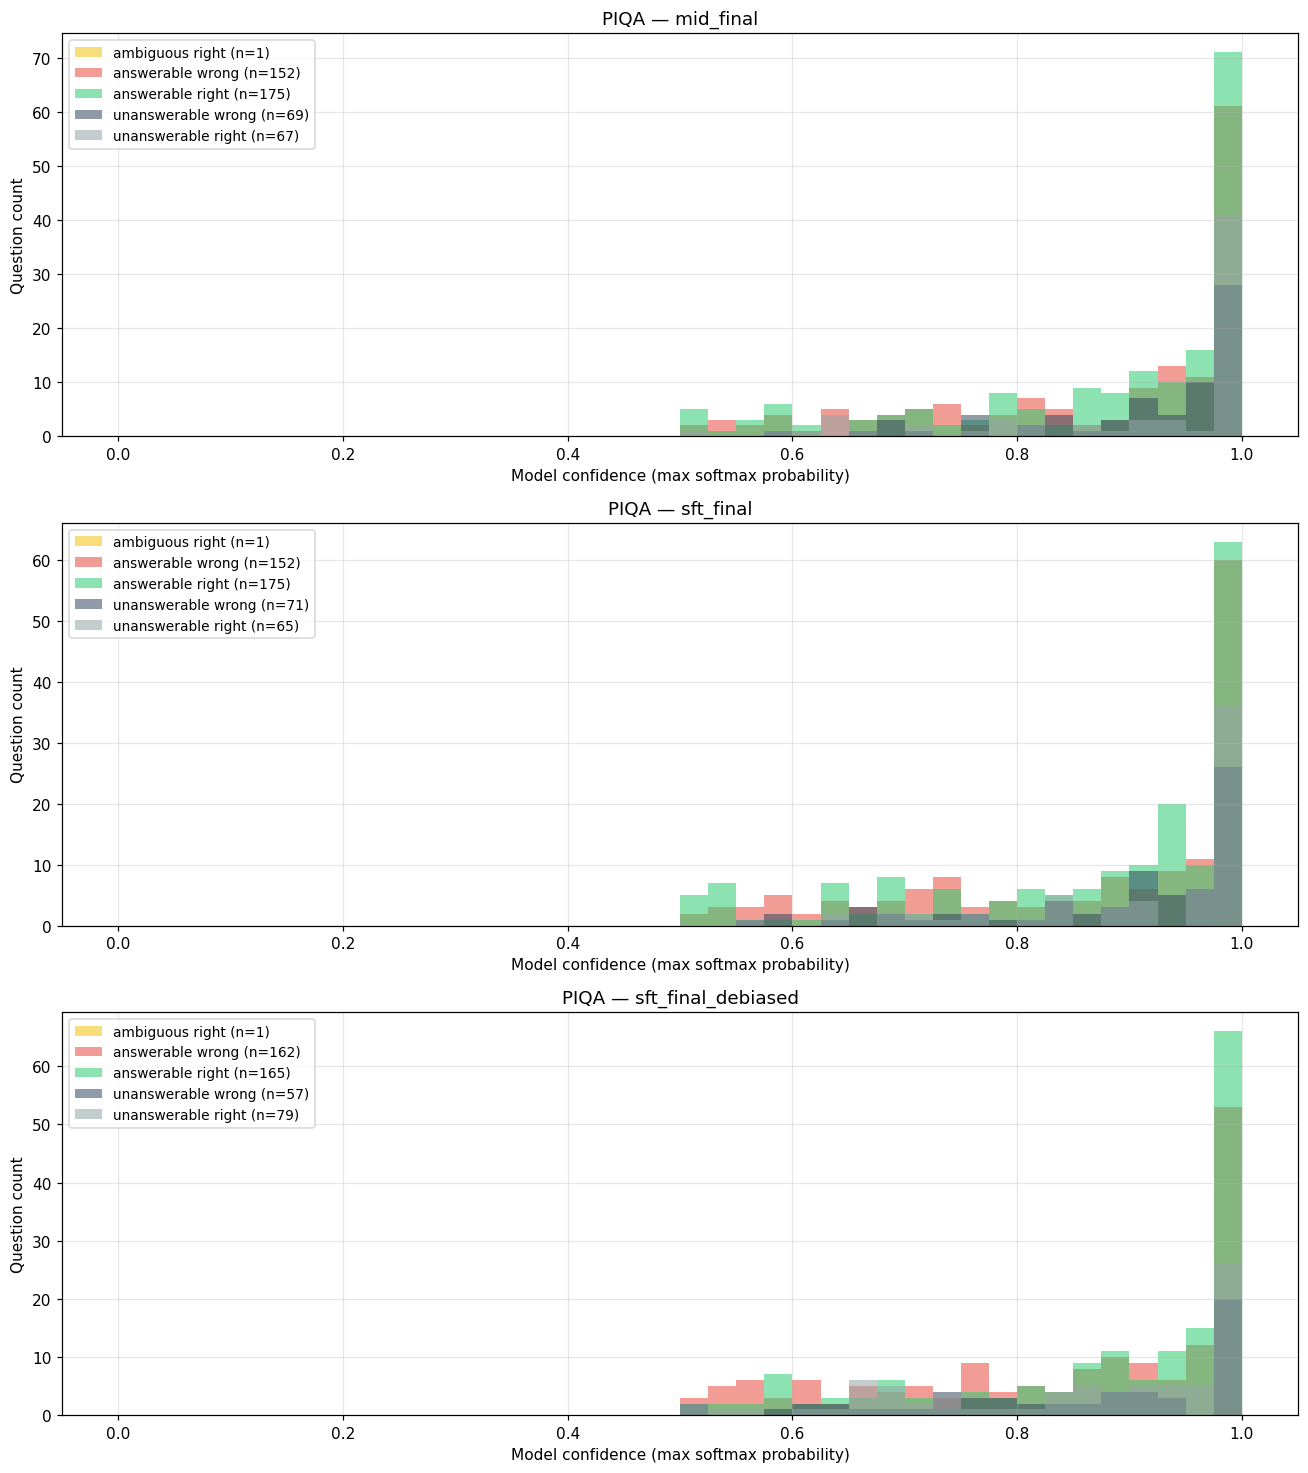

In [5]:
fig, axes = plt.subplots(len([s for s in STAGES if not dfs[s].empty]), 1, figsize=(12, 4.5*len([s for s in STAGES if not dfs[s].empty])))
axes = [axes] if not hasattr(axes, '__iter__') else axes
ax_iter = iter(axes)
for stage in STAGES:
    if dfs[stage].empty: continue
    ax = next(ax_iter)
    plot_confidence_histogram(dfs[stage], classes, title=f'{BENCHMARK} — {stage}', ax=ax)
plt.tight_layout()
plt.show()

## 5. High-Confidence Wrong Answers (answerable subset, Mid phase)

The diagnostic gold. These are questions the model should be able to answer using 1900-1949 knowledge, but got confidently wrong. Review these to identify patterns.

In [6]:
wrong = high_confidence_wrong(dfs['mid_final'], classes, label_filter='answerable', n=20, min_conf=0.5)
print(f'{len(wrong)} high-confidence wrong answers on the answerable subset\n')

for i, (_, row) in enumerate(wrong.iterrows(), 1):
    parsed = extract_stem_and_choices(row['question'])
    print(f'[{i:02d}] conf={row["confidence"]:.0%} pred={row["predicted"]} expected={row["expected"]}')
    print(f'     Q: {parsed["stem"][:280]}')
    for L in sorted(parsed['choices'].keys()):
        mark = ' ← PREDICTED' if L == row['predicted'] else (' ← CORRECT' if L == row['expected'] else '')
        print(f'       {L}: {parsed["choices"][L][:160]}{mark}')
    print()

20 high-confidence wrong answers on the answerable subset

[01] conf=100% pred=B expected=A
     Q: Prevent feet from sweating when wearing flats.
       A: Sprinkle inside of shoes with dry shampoo. ← CORRECT
       B: Sprinkle outside of shoes with dry shampoo. ← PREDICTED

[02] conf=100% pred=B expected=A
     Q: To add fragrance to glycerin for making soap.
       A: Add oils after soap has melted. ← CORRECT
       B: Brush oils after soap had been molded. ← PREDICTED

[03] conf=100% pred=B expected=A
     Q: Remove dust residue from chalk boards.
       A: Wipe down with baby wipes. ← CORRECT
       B: Wipe down with index cards. ← PREDICTED

[04] conf=100% pred=B expected=A
     Q: Remove an ant colony.
       A: Spray a mix of 3/4 water and 1/4 salt on ants. ← CORRECT
       B: Spray a mix of 1/4 water and 3/4 salt on ants. ← PREDICTED

[05] conf=100% pred=B expected=A
     Q: Reduce chances of vomiting.
       A: Take short rapid breaths. ← CORRECT
       B: Take long rapid bre

## 6. Mid vs SFT on Answerable Subset

Did SFT help on the answerable slice, or did it just overfit to internal distribution?

In [7]:
if not dfs['sft_final'].empty:
    mid_trip = accuracy_triple(dfs['mid_final'], classes)
    sft_trip = accuracy_triple(dfs['sft_final'], classes)
    deb_trip = accuracy_triple(dfs['sft_final_debiased'], classes) if not dfs['sft_final_debiased'].empty else None
    rows = []
    for bucket in ['overall','answerable','unanswerable']:
        m = mid_trip.get(bucket,{}).get('acc')
        s = sft_trip.get(bucket,{}).get('acc')
        d = (deb_trip.get(bucket,{}).get('acc') if deb_trip else None)
        if m is None or s is None: continue
        rows.append({
            'bucket': bucket, 'n': mid_trip[bucket]['n'],
            'Mid_%': round(100*m,1), 'SFT_%': round(100*s,1),
            'Debiased_%': round(100*d,1) if d is not None else None,
            'SFT-Mid_delta': round(100*(s-m),1),
        })
    pd.DataFrame(rows)

## 7. Error-Type Clustering

What kinds of questions (within the answerable subset) does the model miss most?

In [8]:
# PIQA: cluster by physical-task domain
import re
DOMAINS = {
    'food/cooking/baking': r'\b(cook|bake|fry|boil|steam|grill|mix|chop|food|meat|vegetable|fruit|dough|recipe)\b',
    'cleaning/household': r'\b(clean|wash|dust|vacuum|stain|dirt|laundry|soap|bleach|detergent|sponge|mop)\b',
    'tools/DIY/repair': r'\b(tool|nail|screw|hammer|saw|drill|fix|repair|glue|tape|paint|sand|cut)\b',
    'crafts/sewing': r'\b(sew|knit|fabric|thread|needle|yarn|button|crochet|stitch|quilt)\b',
    'body/grooming/medical': r'\b(hair|skin|nail|razor|bandage|wound|injur|medicin|first aid|body|face)\b',
}

wrong_df = dfs['mid_final'][dfs['mid_final']['correct'] == False].copy()
wrong_df['qhash'] = wrong_df['question'].map(_hash_question)
wrong_df['label'] = wrong_df['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
ans_wrong = wrong_df[wrong_df['label']=='answerable']

for dom, pat in DOMAINS.items():
    hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]
    print(f'{dom}: {len(hits)} answerable wrong (of {len(ans_wrong)})')
    if len(hits):
        sample = hits.iloc[0]
        parsed = extract_stem_and_choices(sample['question'])
        print(f'  example: {parsed["stem"][:180]}')
    print()

food/cooking/baking: 25 answerable wrong (of 152)
  example: How to make mashed potatoes.

cleaning/household: 22 answerable wrong (of 152)
  example: mop

tools/DIY/repair: 33 answerable wrong (of 152)
  example: how do you eat boiled egg?

crafts/sewing: 5 answerable wrong (of 152)
  example: What materials are needed to hand sew an article of clothing?

body/grooming/medical: 9 answerable wrong (of 152)
  example: washcloth



C:\Users\danielyoon\AppData\Local\Temp\ipykernel_31124\299940120.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]


## 8. Verdict

Interpretation based on the answerable-subset accuracy:

- **answerable_acc > random + 15pp**: Real skill transfer. Model has the capability.
- **answerable_acc within ±5pp of random**: Skill gap. The model can't reason about even period-compatible content.
- **answerable_acc >> overall_acc**: Content gap dominates. Targeted synthetic data on modern vocabulary could help.
- **high-conf wrong clusters around one error type**: Targeted fix possible — rewrite the corresponding generator.

In [9]:
# Verdict computation
trip = accuracy_triple(dfs['mid_final'], classes)
overall = trip.get('overall', {}).get('acc', 0) or 0
answerable = trip.get('answerable', {}).get('acc', 0) or 0
unanswerable = trip.get('unanswerable', {}).get('acc', 0) or 0

verdict = []
if answerable > RANDOM_BASELINE + 0.15:
    verdict.append(f'✅ Real skill transfer: answerable={100*answerable:.1f}% vs random={100*RANDOM_BASELINE:.0f}%')
elif abs(answerable - RANDOM_BASELINE) < 0.05:
    verdict.append(f'⚠️ Skill gap: answerable subset at {100*answerable:.1f}% (near random).')
else:
    verdict.append(f'➖ Modest transfer: answerable={100*answerable:.1f}%, +{100*(answerable-RANDOM_BASELINE):.1f}pp vs random.')

if answerable - overall > 0.05:
    verdict.append(f'📈 Content gap contributes: answerable ({100*answerable:.1f}%) beats overall ({100*overall:.1f}%) by {100*(answerable-overall):.1f}pp.')

if unanswerable > RANDOM_BASELINE + 0.05:
    verdict.append(f'⚠️ Unanswerable subset at {100*unanswerable:.1f}% — model may be leaking modern knowledge.')

print('\n'.join(verdict))

⚠️ Skill gap: answerable subset at 53.5% (near random).
